# Building a Fully Connected Network (FCN) for Devnagari Digit Classification.

# Setting the environment

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile #For handling zipped files
import os #For navigating folders

zip_path = '/content/drive/MyDrive/AI_ML/Copy of devnagari digit.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset') #Extract ALL contents to /content/dataset folder


Mounted at /content/drive


## Task 1: Data Preparation

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


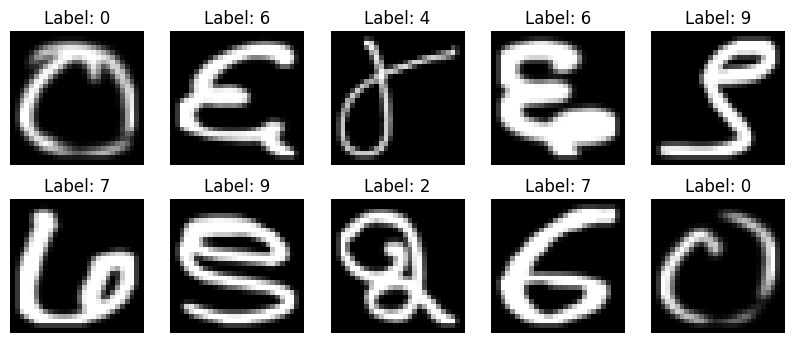

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical #Deep learning framework which converts labels to one hot
# from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image  # Import Pillow

# Define dataset paths
train_dir = "/content/dataset/DevanagariHandwrittenDigitDataset/Train/"
test_dir = "/content/dataset/DevanagariHandwrittenDigitDataset/Test/"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = [] #store images
    labels = [] #Store thier labels

    class_names = sorted(os.listdir(folder))  # Sorted class names
    class_map = {name: i for i, name in enumerate(class_names)}  # Map class names to labels

    for class_name in class_names: #Loops through each digit class
        class_path = os.path.join(folder, class_name) #Builds the full path
        label = class_map[class_name] #Retrieves the numeric value

        for filename in os.listdir(class_path): #Loops through every image file inside that class folder
            img_path = os.path.join(class_path, filename) #Builds its full path.

            # Load image using PIL
            img = Image.open(img_path).convert("L")  # Convert to grayscale
            img = img.resize((img_width, img_height))  # Resize to (28,28)
            img = np.array(img) / 255.0  # Converts PIL image to NumPy array then normalizes

            images.append(img) #Adds image to list
            labels.append(label) #Adds corresponding label

    return np.array(images), np.array(labels) #Converts to array

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir) #For training data
x_test, y_test = load_images_from_folder(test_dir) #For testing data

#Shuffling
shuffle_idx = np.random.permutation(len(x_train)) #Generates a random index order
x_train, y_train = x_train[shuffle_idx], y_train[shuffle_idx] #Reorders both images and labels the same way

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) #keeps number of images, reshape each to 28×28×1
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10) # Converts integer labels to one-hot vectors for 10 classes
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1) #2 rows, 5 columns, position i+1
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray') #Removes the channel dimension
    plt.title(f"Label: {np.argmax(y_train[i])}") #Convert one-hot back to digit for title
    plt.axis("off")


##Task 2: Build the FCN Model

In [12]:
import tensorflow as tf
from tensorflow import keras

num_classes = 10 #We have 10 digits (0-9) to classify
input_shape = (28, 28, 1) #Each input image: 28×28 pixels, grayscale

#Create Sequential Model
model = keras.Sequential([
    #Layer 1: Input Layer
    keras.layers.Input(shape=input_shape), #Defines what shape of data enters the model
    #Layer 2: Flatten Layer
    keras.layers.Flatten(),  # handles flattening 28x28x1 → 784 no parameters
    #Layer 3: First Hidden Layer (Dense 64)
    keras.layers.Dense(64, activation="sigmoid"),
    #Layer 4: Second Hidden Layer (Dense 128)
    keras.layers.Dense(128, activation="sigmoid"),
    #Layer 5: Third Hidden Layer (Dense 256)
    keras.layers.Dense(256, activation="sigmoid"),
    #Layer 6: Output Layer (Dense 10)
    keras.layers.Dense(num_classes, activation="softmax"),
])
#Parameters = i*o +b
#Output=sigmoid(w*x)+b

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

##Task 3: Compile the Model

In [4]:
#This is where how the model will learn is configured
model.compile(
    optimizer='adam', #automatically adjusts the learning rate
    loss='categorical_crossentropy', #Measures how "wrong" the model's predictions are
    metrics=['accuracy'] #Monitors model performance during training
)

##Task 4: Train the Model

In [5]:
#Model "sees" the data and learns to recognize the digits
history = model.fit(
    x_train, # Training images
    y_train, ## Training labels
    batch_size=128, # Process 128 images before updating weights
    epochs=20, #model will go through the entire dataset 20 times
    validation_split=0.2 #20% of your training data to test itself after every epoch
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4029 - loss: 1.9330 - val_accuracy: 0.7303 - val_loss: 1.1711
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7954 - loss: 0.7335 - val_accuracy: 0.8215 - val_loss: 0.4806
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8753 - loss: 0.3844 - val_accuracy: 0.9082 - val_loss: 0.3223
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9266 - loss: 0.2620 - val_accuracy: 0.9394 - val_loss: 0.2303
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9482 - loss: 0.1900 - val_accuracy: 0.9515 - val_loss: 0.1873
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9585 - loss: 0.1480 - val_accuracy: 0.9582 - val_loss: 0.1563
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9663 - loss: 0.1206 - val_accuracy: 0.9615 - val_loss: 0.1439
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9727 - loss: 0.0973 - val_accuracy: 0.

## Task 5: Evaluate the Model

In [6]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9780 - loss: 0.0815
Test Accuracy: 0.9780
Test Loss: 0.0815


## Task 6: Save and Load the Model

In [7]:
# Save
model.save('devnagari_fcn_model.h5') #Saves weights, biases, and the architecture that was just trained
print("Model saved as 'devnagari_fcn_model.h5'")

# Load (to verify)
from tensorflow.keras.models import load_model
loaded_model = load_model('devnagari_fcn_model.h5')
print("Model loaded successfully!")

# Verify loaded model works
loss, acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Loaded model accuracy: {acc:.4f}")

Model saved as 'devnagari_fcn_model.h5'


Model loaded successfully!
Loaded model accuracy: 0.9780


## Task 7: Predictions

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


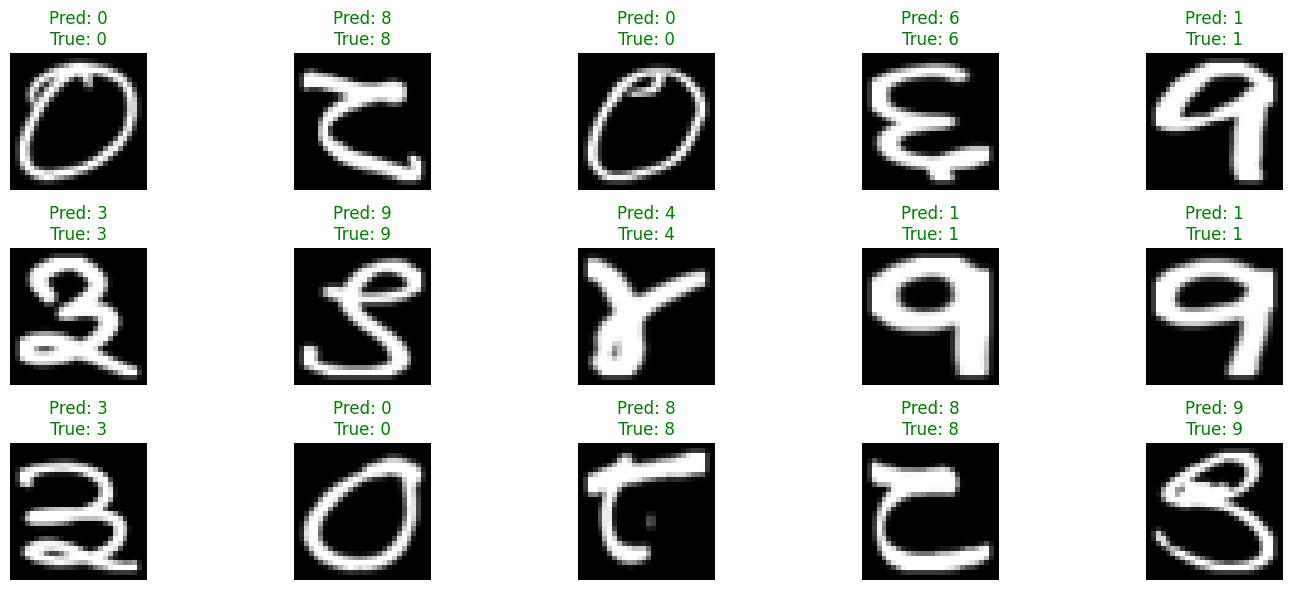

In [9]:
# Shuffle test data for better visualization
shuffle_test = np.random.permutation(len(x_test)) #creates a random ordering of numbers 0 to 2999 for x_test=3000

x_test_vis = x_test[shuffle_test] #Shuffle Test Images
true_labels_vis = true_labels[shuffle_test] #Shuffle True Labels
#Getting Model Predictions
pred_vis = np.argmax(loaded_model.predict(x_test_vis), axis=1) #Convert the model’s predicted probabilities to digit labels

plt.figure(figsize=(15, 6))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(x_test_vis[i].reshape(28, 28), cmap='gray')
    color = 'green' if pred_vis[i] == true_labels_vis[i] else 'red'
    plt.title(f"Pred: {pred_vis[i]}\nTrue: {true_labels_vis[i]}", color=color)
    plt.axis('off')
plt.tight_layout()


# Visualization

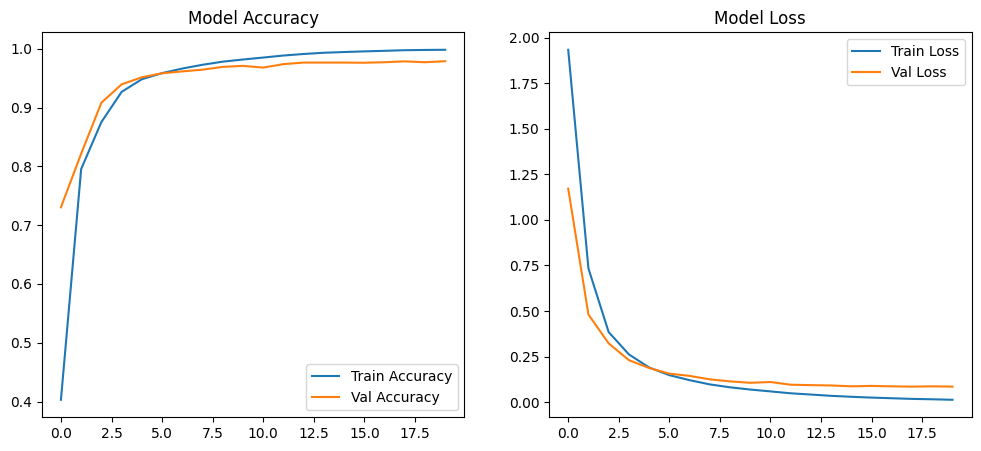

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted Label: 0
True Label: 0


In [10]:
# Visualization: Training and Validation Accuracy/Loss
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

# Task 7: Making Predictions
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1) # Convert probabilities to labels

# Show the first test prediction
print(f"Predicted Label: {predicted_labels[0]}")
print(f"True Label: {np.argmax(y_test[0])}")